# 2. NIfTI I/O

Load an aligned NIfTI dose and structure set, check their geometry, and inspect both containers and raw array data.


In [1]:
from dosemetrics import Dose
from dosemetrics.io import detect_folder_format, load_structure_set, load_volume
from dosemetrics.utils import download_example_data, dose_statistics_table, plot_dose_slice

study_dir = download_example_data("test_subject")
dose = Dose.from_nifti(study_dir / "Dose.nii.gz", name="Clinical")
structures = load_structure_set(study_dir, format="nifti")

print(f"Format: {detect_folder_format(study_dir)}")
print(f"Dose grid: {dose.shape}, spacing={dose.spacing} mm")
print(f"Structures: {len(structures)}")


Format: nifti
Dose grid: (128, 128, 128), spacing=(2.0, 2.0, 2.0) mm
Structures: 16


## Check dose and contour alignment


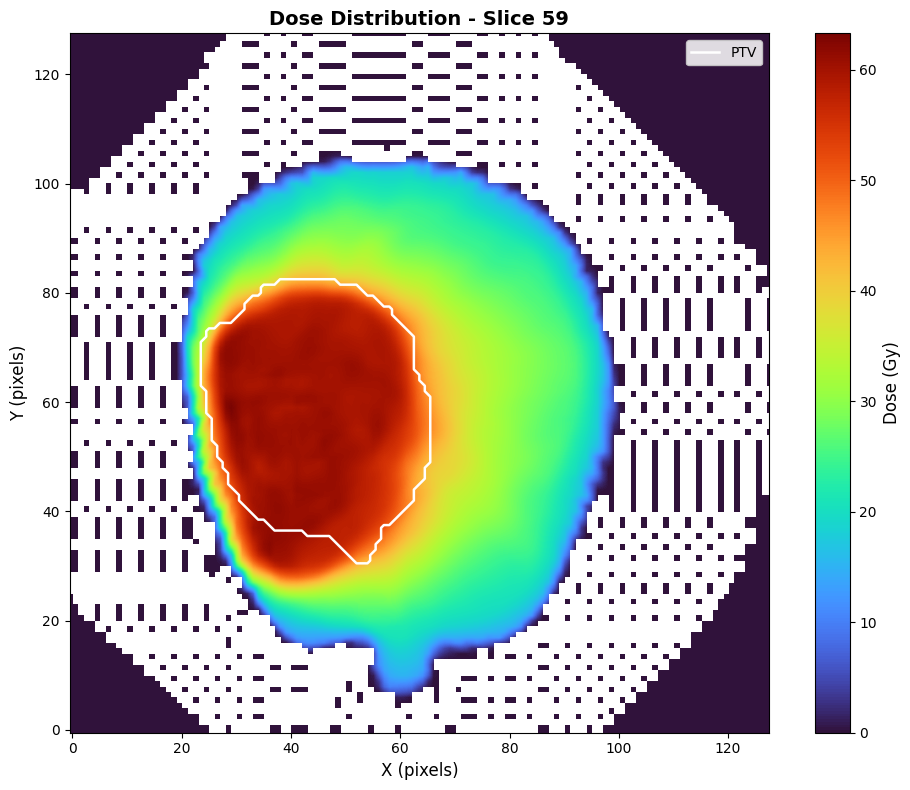

In [2]:
plot_dose_slice(
    dose,
    structures=structures,
    structure_names=["PTV", "Brainstem", "Chiasm"],
    contour_colors={"PTV": "white", "Brainstem": "lime", "Chiasm": "cyan"},
    cmap="turbo",
);


## Summarize several structures


In [3]:
dose_statistics_table(dose, structures, ["PTV", "Brainstem", "Chiasm"]).round(2)


,Volume (cc),Mean dose (Gy),Minimum dose (Gy),Maximum dose (Gy),D98 (Gy),D95 (Gy),D50 (Gy),D02 (Gy)
Structure,,,,,,,,
PTV,343.03,58.13,31.72,63.90,45.08,48.17,59.81,61.48
Brainstem,31.06,58.42,41.11,61.65,47.93,50.66,60.00,61.19
Chiasm,0.96,54.46,43.19,60.52,43.86,45.23,56.66,59.81


## Access a raw array

Use `load_volume` when you need the array and spatial metadata without a `Dose` container.


In [4]:
volume, spacing, origin = load_volume(study_dir / "Dose.nii.gz")
print(f"Array: shape={volume.shape}, dtype={volume.dtype}")
print(f"Spacing: {spacing} mm; origin: {origin} mm")


Array: shape=(128, 128, 128), dtype=float32
Spacing: (2.0, 2.0, 2.0) mm; origin: (92.70909881591797, 80.26853942871094, 52.468624114990234) mm
